# 07b — OE Image Inversion with Dask (LUT bottom)

Same as NB07 but uses the spectral **look-up table (LUT)** bottom reflectance
from `precompute()` instead of a measured per-pixel albedo image.

The LUT contains 6 endmember spectra (`R_b_i`, shape `(n_bands, 6)`).
Bottom type fractions are either fixed (`f_0 = 1` for a single type) or
retrieved via the **softmax parameterization** (`f_mix_*` in `fit_config`),
which guarantees non-negative fractions that sum to 1.

Use this notebook when:
- No co-located low-tide image is available
- You want to retrieve benthic composition (fraction of each LUT type)
- You want to compare LUT-based vs. image-based bottom constraints

In [16]:
import os
import numpy as np
import xarray as xr
import lmfit
import dask
import matplotlib.pyplot as plt
import jax.numpy as jnp
import cmocean.cm as cm

from bio_optics.inversion import oe_engine, dask_oe_engine
from bio_optics.reflectance import albert_mobley_jax

## Get data

Same Sentinel-2 Wadden Sea scene as NB04: two time steps at the same location.
Time 0 = low tide (benthic reflectance visible), Time 1 = high tide (water-leaving Rrs).

In [17]:
dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))
dataset

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 2, x: 449, y: 267)
Coordinates:
  * time         (time) datetime64[ns] 16B 2023-09-06T10:35:55 2023-09-11T10:...
  * x            (x) float64 4kB 4.761e+05 4.761e+05 ... 4.806e+05 4.806e+05
  * y            (y) float64 2kB 6.05e+06 6.05e+06 ... 6.047e+06 6.047e+06
    spatial_ref  int32 4B ...
Data variables:
    crs          int32 4B ...
    B02          (time, y, x) float32 959kB ...
    B03          (time, y, x) float32 959kB ...
    B04          (time, y, x) float32 959kB ...
    B05          (time, y, x) float32 959kB ...
    B06          (time, y, x) float32 959kB ...
    B07          (time, y, x) float32 959kB ...
    B08          (time, y, x) float32 959kB ...
    B8A          (time, y, x) float32 959kB ...
Attributes:
    Conventions:             CF-1.7
    date_created:            2024-06-10T12:36:20.350532
    processing_level:        L2A
    time_coverage_duration:  P4DT23H59M59S
    time_coverage_end:       2023-09-11T10:35:54+00:00
    time_coverage_start:     2023-09-06T10:35:55+00:00
    title:                   S2L2A Data Cube Subset

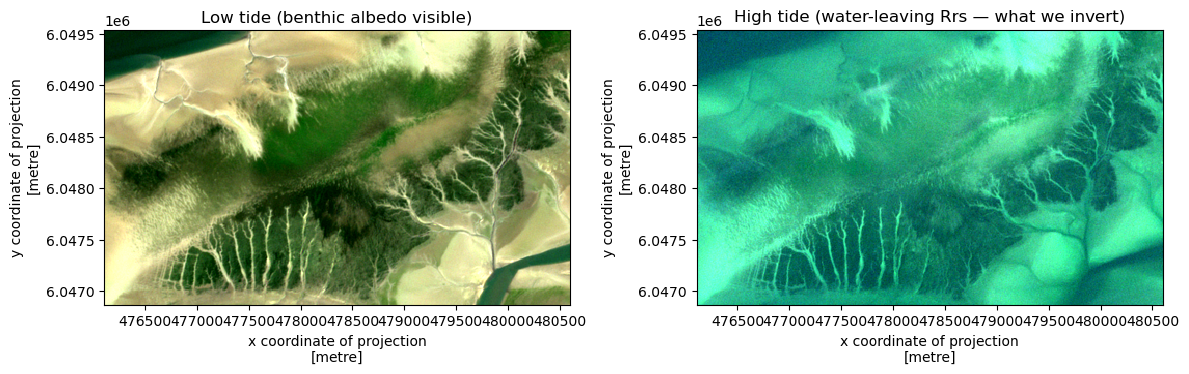

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dataset[['B04', 'B03', 'B02']].isel(time=0).to_array().plot.imshow(robust=True, ax=axes[0])
axes[0].set_title('Low tide (benthic albedo visible)')
dataset[['B04', 'B03', 'B02']].isel(time=1).to_array().plot.imshow(robust=True, ax=axes[1])
axes[1].set_title('High tide (water-leaving Rrs — what we invert)')
plt.tight_layout()
plt.show()

## Prepare arrays

- `Rrs_image`: high-tide reflectance divided by π → Rrs [sr⁻¹], shape (n_rows, n_cols, n_obs)

The low-tide image is loaded only for the RGB overview plot; it is **not** used in the inversion.

In [19]:
wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])

band_vars = list(dataset.data_vars)[1:]   # skip the first variable (time or similar)

# --- detect spatial dimension names and order from the dataset ---------------
ref_band = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(ref_band.dims)          # e.g. ['y', 'x']
print('Spatial dims in dataset:', spatial_dim_names)

spatial_coords = {d: dataset[d].values for d in spatial_dim_names if d in dataset.coords}

# --- high-tide Rrs (what we invert) ------------------------------------------
Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi
print('Rrs_image shape:', Rrs_image.shape)    # (dim0, dim1, n_obs)

Spatial dims in dataset: ['y', 'x']
Rrs_image shape: (267, 449, 8)


## Precompute

Run the spectral lookup table resampling once. The `R_b_i` entry already contains
the 6 LUT endmember spectra and is used as-is — no per-pixel override needed.

In [20]:
pre_base = albert_mobley_jax.precompute(wavelengths)
print('precomputed keys:', list(pre_base.keys()))

precomputed keys: ['wavelengths', 'a_w', 'da_w_div_dT', 'a_i_spec', 'b_phy_norm', 'bb_w', 'b_X_norm', 'R_b_i']


## Configuration

Edit **only this cell** to change which parameters are retrieved and with what priors.

| Key | Meaning |
|---|---|
| `vary` | `True` = free parameter (retrieved), `False` = fixed at `value` |
| `value` | Initial / fixed value in physical units |
| `sigma_a` | Prior uncertainty in retrieval space: fractional for log-params (0.7 ≈ ×2), physical std for linear params |
| `log` | `True` = retrieve in log-space (recommended for strictly positive quantities) |

**`bottom_types`** selects which LUT endmembers to use (indices into `R_b_i`):

| Index | Type |
|---|---|
| 0 | constant 10% |
| 1 | sand |
| 2 | coral |
| 3 | CCA (crustose coralline algae) |
| 4 | macrophyte |
| 5 | seagrass (*Zostera marina*) |

The selected types are remapped to positions 0, 1, … in the forward model.  
Add `f_mix_0`, `f_mix_1`, … to `fit_config` to retrieve their mixing fractions via softmax
(N free logits + 1 reference logit fixed at 0 → N+1 non-negative fractions summing to 1).

In [21]:
# ── Retrieval configuration — edit here only ─────────────────────────────────
bottom_types = [1, 5]   # LUT indices to use: 1=sand, 5=seagrass

fit_config = {
    'C_0':   dict(vary=False, value=0.5,  sigma_a=1.0, log=True),   # chl [mg/m³]
    'C_Y':   dict(vary=False, value=0.1,  sigma_a=1.0, log=True),   # CDOM [1/m]
    'C_Mie': dict(vary=False, value=0.1,  sigma_a=1.0, log=True),   # SPM [g/m³]
    'zB':    dict(vary=True,  value=0.5,  sigma_a=0.7, log=True),   # depth [m]
    # Softmax bottom mixing: one f_mix per type except the last (reference, logit=0).
    # With bottom_types=[1,5]: f_mix_0 controls sand vs seagrass.
    'f_mix_0': dict(vary=True, value=0.0, sigma_a=2.0, log=False),
}

noise     = 0.0031   # measurement std [sr⁻¹]
n_iter    = 15
tile_size = 4096    # pixels per Dask tile

# ── Plot metadata for all possible parameters (label, unit, colormap) ─────────
_LUT_NAMES = ['const10%', 'sand', 'coral', 'CCA', 'macrophyte', 'seagrass']
PARAM_META = {
    'C_0':   ('Chlorophyll C₀', 'mg m⁻³', 'Greens'),
    'C_Y':   ('CDOM C_Y',       'm⁻¹',    'YlOrBr'),
    'C_Mie': ('SPM C_Mie',      'g m⁻³',  'Oranges'),
    'zB':    ('Depth z_B',      'm',       cm.deep),
}

# ── Derived — no edits needed below ──────────────────────────────────────────
params = lmfit.Parameters()

# Geometry
params.add('theta_sun',  value=np.radians(30), vary=False)
params.add('theta_view', value=np.radians(0),  vary=False)
params.add('n1',         value=1.0,            vary=False)
params.add('n2',         value=1.33,           vary=False)
params.add('kappa_0',    value=1.0546,         vary=False)

# Water constituents
params.add('C_0',   value=fit_config['C_0']['value'],   vary=fit_config['C_0']['vary'])
params.add('C_Y',   value=fit_config['C_Y']['value'],   vary=fit_config['C_Y']['vary'])
params.add('C_Mie', value=fit_config['C_Mie']['value'], vary=fit_config['C_Mie']['vary'])
params.add('C_1',   value=0.0, vary=False)
params.add('C_2',   value=0.0, vary=False)
params.add('C_3',   value=0.0, vary=False)
params.add('C_4',   value=0.0, vary=False)
params.add('C_5',   value=0.0, vary=False)
params.add('C_X',   value=0.0, vary=False)

# IOP parameters
params.add('S',                   value=0.014,  vary=False)
params.add('S_NAP',               value=0.011,  vary=False)
params.add('lambda_0',            value=440.0,  vary=False)
params.add('K',                   value=0.0,    vary=False)
params.add('T_W',                 value=18.0,   vary=False)
params.add('T_W_0',               value=20.0,   vary=False)
params.add('a_NAP_spec_lambda_0', value=0.041,  vary=False)
params.add('bb_phy_spec',         value=0.0010, vary=False)
params.add('bb_Mie_spec',         value=0.0042, vary=False)
params.add('bb_X_spec',           value=0.0086, vary=False)
params.add('lambda_S',            value=500.0,  vary=False)
params.add('n',                   value=-1.0,   vary=False)

# Bottom — all 6 slots; active types filled by the precompute cell
for i in range(6):
    params.add(f'f_{i}', value=1.0 if i == 0 else 0.0, vary=False)
    params.add(f'B_{i}', value=1/np.pi, vary=False)

# Optional softmax bottom mixing
for name in sorted(n for n in fit_config if n.startswith('f_mix_')):
    params.add(name, value=fit_config[name]['value'], vary=fit_config[name]['vary'])
    idx = int(name.split('_')[-1])
    lut_name = _LUT_NAMES[bottom_types[idx]] if idx < len(bottom_types) else str(idx)
    PARAM_META[name] = (f'Mix logit ({lut_name})', 'logit', 'RdYlGn')

# Depth
params.add('zB', value=fit_config['zB']['value'], vary=fit_config['zB']['vary'])

# OE prior derived from fit_config
sigma_a    = {n: c['sigma_a'] for n, c in fit_config.items() if c['vary']}
log_params = [n for n, c in fit_config.items() if c['vary'] and c['log']]

print('Free parameters:', [n for n in params if params[n].vary])
print('log_params:',       log_params)
print('sigma_a:',          sigma_a)
print('bottom_types:',     [f'{i} ({_LUT_NAMES[i]})' for i in bottom_types])

Free parameters: ['f_mix_0', 'zB']
log_params: ['zB']
sigma_a: {'zB': 0.7, 'f_mix_0': 2.0}
bottom_types: ['1 (sand)', '5 (seagrass)']


## Run inversion

The LUT bottom spectra are already baked into `precomputed` — no `aux_image` needed.
Bottom type fractions are either fixed (`f_0 = 1`, default) or retrieved via
softmax logits (`f_mix_*` in `fit_config`).

In [ ]:
all_names = list(params.keys())

# Remap R_b_i so selected bottom_types appear at positions 0, 1, ...
R_b_full = np.array(pre_base['R_b_i'])          # (n_bands, 6)
R_b_selected = np.zeros_like(R_b_full)
for dst, src in enumerate(bottom_types):
    R_b_selected[:, dst] = R_b_full[:, src]
pre = {**pre_base, 'R_b_i': jnp.array(R_b_selected)}
print('active bottom slots:', {dst: f'{src} ({_LUT_NAMES[src]})' for dst, src in enumerate(bottom_types)})

# Build one forward function and setup for the whole image
f_vec = albert_mobley_jax.make_forward_vec(all_names, pre)
setup = oe_engine.build_inversion(params, f_vec, sigma_a, log_params=log_params)

# Warm up JAX JIT before the timed inversion
print('Warming up JIT ...')
dask_oe_engine.warmup_jit(setup, noise, n_iter=n_iter, tile_size=tile_size)
print(f'Running inversion — {Rrs_image.shape[0]*Rrs_image.shape[1]} pixels, tile_size={tile_size}...')

results = dask_oe_engine.invert_image(
    Rrs_image, setup, noise,
    n_iter=n_iter,
    tile_size=tile_size,
    store_y_hat=True,
)
print('Done.')


In [23]:
ds = dask_oe_engine.to_dataset(
    results,
    spatial_dims=tuple(spatial_dim_names),
    coords=spatial_coords,
)

# param_labels derived from what was actually retrieved
param_labels = {n: PARAM_META[n] for n in setup.fit_names if n in PARAM_META}

ds

<xarray.Dataset> Size: 14MB
Dimensions:  (y: 267, x: 449, param: 2, band: 8)
Coordinates:
  * y        (y) float64 2kB 6.05e+06 6.05e+06 6.05e+06 ... 6.047e+06 6.047e+06
  * x        (x) float64 4kB 4.761e+05 4.761e+05 ... 4.806e+05 4.806e+05
  * param    (param) <U7 56B 'f_mix_0' 'zB'
  * band     (band) int32 32B 0 1 2 3 4 5 6 7
Data variables:
    x_hat    (y, x, param) float64 2MB -1.606 0.4102 -1.499 ... -0.8168 0.4546
    sigma    (y, x, param) float64 2MB 0.3493 0.07397 0.3311 ... 0.2438 0.07981
    A_diag   (y, x, param) float64 2MB 0.9695 0.9336 0.9726 ... 0.9851 0.9371
    chi2     (y, x) float64 959kB 1.083 1.205 1.302 1.157 ... 1.255 1.439 1.414
    y_hat    (y, x, band) float64 8MB 0.007076 0.01234 ... 0.001039 0.0004251

## Goodness of fit — χ²

χ² ≈ 1 means the residuals match the assumed noise level.  
χ² >> 1 flags model–data mismatch: cloud shadows, emergent vegetation, or
optically deep pixels where the shallow-water model is inappropriate.

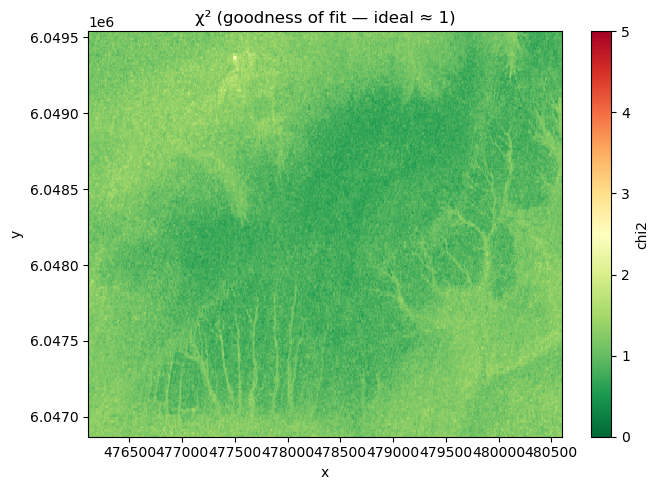

Median χ²: 1.02
Pixels with χ² > 3: 0 / 119883


In [24]:
chi2_all = results['chi2']

fig, ax = plt.subplots(figsize=(7, 5))
ds['chi2'].plot(ax=ax, vmin=0, vmax=5, cmap='RdYlGn_r')
ax.set_title('χ² (goodness of fit — ideal ≈ 1)')
plt.tight_layout()
plt.show()

print(f'Median χ²: {float(np.nanmedian(chi2_all)):.2f}')
print(f'Pixels with χ² > 3: {(chi2_all > 3).sum()} / {chi2_all.size}')

### Noise calibration check

χ² tells you directly whether the noise assumption is correct:

| χ² | Interpretation | Action |
|---|---|---|
| ≈ 1 | noise well-calibrated | — |
| >> 1 | noise underestimated (σ too small) | increase `noise` |
| << 1 | noise overestimated (σ too large) | decrease `noise` |

The **implied noise** `σ_implied = noise × √(median χ²)` is the σ that would give χ² = 1.
The **residual spectrum** (y_obs − y_hat) should look like structureless noise within ±σ.
Any systematic pattern at a specific wavelength indicates model error there.

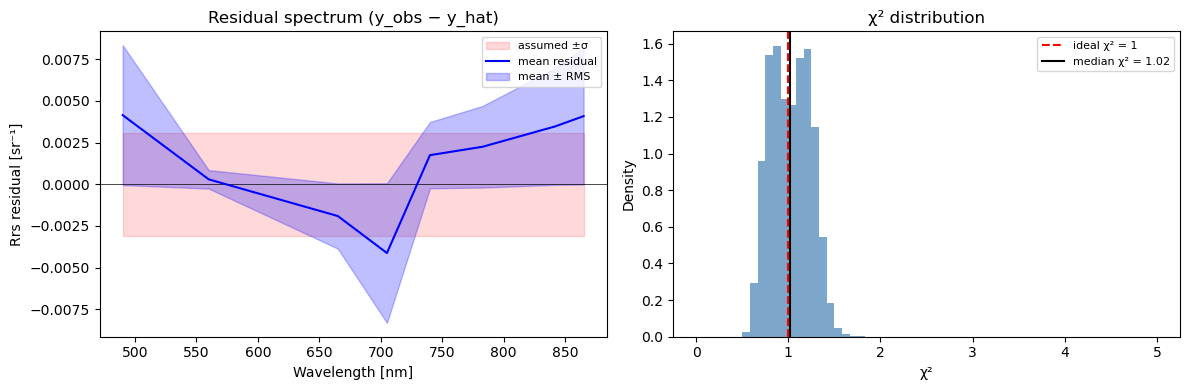

Assumed noise σ:       0.0031 sr⁻¹
Median χ²:             1.020
Implied noise (χ²→1):  0.0031 sr⁻¹  (= noise × √χ²)
→ noise assumption looks reasonable


In [25]:
residuals    = Rrs_image - results['y_hat']                      # (n_rows, n_cols, n_obs)
resid_mean   = np.nanmean(residuals,    axis=(0, 1))             # (n_obs,)
resid_rms    = np.sqrt(np.nanmean(residuals**2, axis=(0, 1)))    # (n_obs,)
chi2_median  = float(np.nanmedian(results['chi2']))
noise_implied = noise * np.sqrt(chi2_median)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: residual spectrum
ax = axes[0]
ax.axhline(0, color='k', lw=0.5)
ax.fill_between(wavelengths, -noise, noise, alpha=0.15, color='r', label='assumed ±σ')
ax.plot(wavelengths, resid_mean, 'b-',  label='mean residual')
ax.fill_between(wavelengths, resid_mean - resid_rms, resid_mean + resid_rms,
                alpha=0.25, color='b', label='mean ± RMS')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Rrs residual [sr⁻¹]')
ax.set_title('Residual spectrum (y_obs − y_hat)')
ax.legend(fontsize=8)

# Right: chi2 histogram
ax = axes[1]
chi2_valid = results['chi2'][np.isfinite(results['chi2'])]
ax.hist(chi2_valid.ravel(), bins=60, range=(0, 5), color='steelblue', alpha=0.7, density=True)
ax.axvline(1.0,        color='r', ls='--', lw=1.5, label='ideal χ² = 1')
ax.axvline(chi2_median, color='k', ls='-',  lw=1.5, label=f'median χ² = {chi2_median:.2f}')
ax.set_xlabel('χ²')
ax.set_ylabel('Density')
ax.set_title('χ² distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Assumed noise σ:       {noise:.4f} sr⁻¹')
print(f'Median χ²:             {chi2_median:.3f}')
print(f'Implied noise (χ²→1):  {noise_implied:.4f} sr⁻¹  (= noise × √χ²)')
if chi2_median < 0.7:
    print(f'→ noise likely overestimated — try noise = {noise_implied:.4f}')
elif chi2_median > 1.5:
    print(f'→ noise likely underestimated — try noise = {noise_implied:.4f}')
else:
    print('→ noise assumption looks reasonable')

## Retrieved parameters

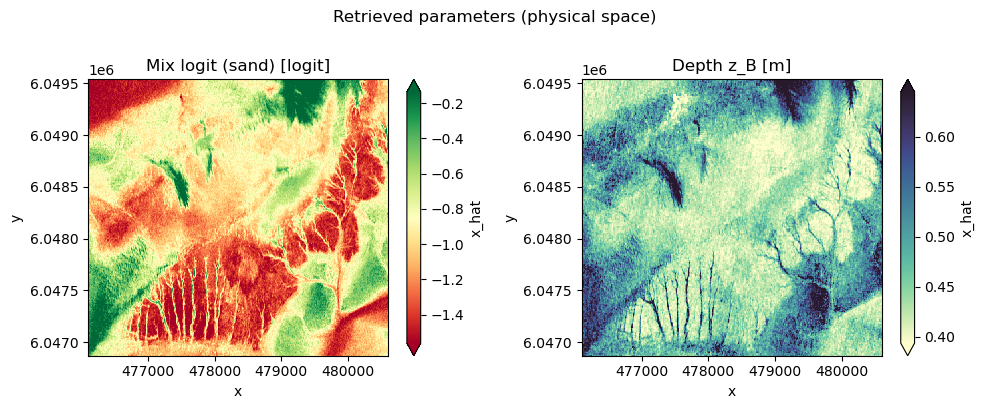

In [26]:
n_fit = len(param_labels)
fig, axes = plt.subplots(1, n_fit, figsize=(5 * n_fit, 4)) if n_fit > 1 else plt.subplots(1, 1, figsize=(5, 4))
axes = np.atleast_1d(axes)

for ax, (param, (label, unit, cmap)) in zip(axes, param_labels.items()):
    ds['x_hat'].sel(param=param).plot(ax=ax, cmap=cmap, robust=True)
    ax.set_title(f'{label} [{unit}]')

plt.suptitle('Retrieved parameters (physical space)', y=1.01)
plt.tight_layout()
plt.show()

## Posterior uncertainty — σ

σ is the posterior standard deviation in **physical space** (delta-method for log-params).  
Compare σ to the prior to see how much the data constrained each parameter.

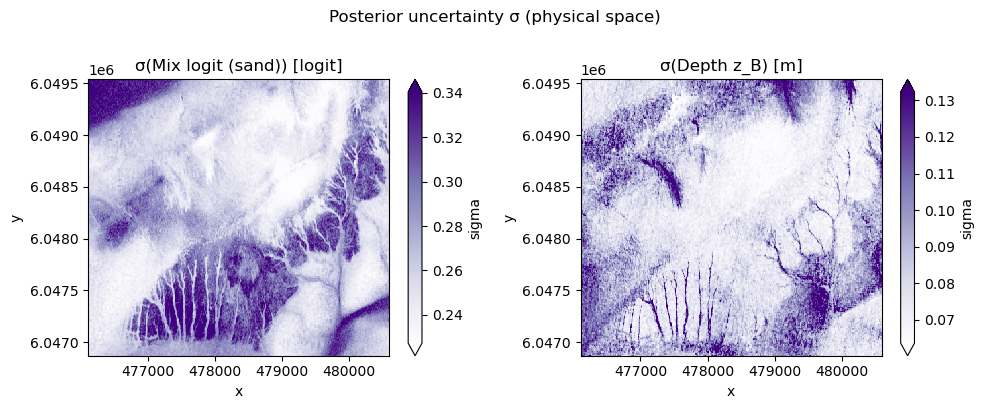

In [27]:
fig, axes = plt.subplots(1, n_fit, figsize=(5 * n_fit, 4)) if n_fit > 1 else plt.subplots(1, 1, figsize=(5, 4))
axes = np.atleast_1d(axes)

for ax, (param, (label, unit, _)) in zip(axes, param_labels.items()):
    ds['sigma'].sel(param=param).plot(ax=ax, cmap='Purples', robust=True)
    ax.set_title(f'σ({label}) [{unit}]')

plt.suptitle('Posterior uncertainty σ (physical space)', y=1.01)
plt.tight_layout()
plt.show()

## Averaging kernel diagonal — A

A[i,i] ∈ [0, 1]: fraction of the retrieved value that comes from the data
(vs. the prior).  A ≈ 1 = fully data-driven; A ≈ 0 = mostly prior.

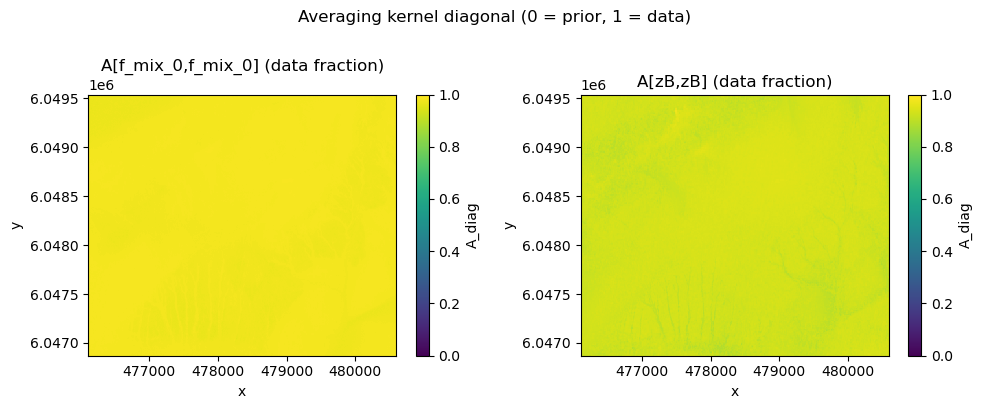

Median DFS: 1.91 / 2 parameters


In [28]:
fig, axes = plt.subplots(1, n_fit, figsize=(5 * n_fit, 4)) if n_fit > 1 else plt.subplots(1, 1, figsize=(5, 4))
axes = np.atleast_1d(axes)

for ax, (param, (label, _, __)) in zip(axes, param_labels.items()):
    ds['A_diag'].sel(param=param).plot(ax=ax, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'A[{param},{param}] (data fraction)')

plt.suptitle('Averaging kernel diagonal (0 = prior, 1 = data)', y=1.01)
plt.tight_layout()
plt.show()

A_diag_all = results['A_diag']
dfs = A_diag_all.sum(axis=-1)
print(f'Median DFS: {np.nanmedian(dfs):.2f} / {len(setup.fit_names)} parameters')

## Per-parameter summary

In [29]:
x_hat_all  = results['x_hat']
sigma_all  = results['sigma']
A_diag_all = results['A_diag']

header = f"{'Parameter':<10}  {'median x_hat':>12}  {'median sigma':>12}  {'median A[i,i]':>13}"
print(header)
print('-' * len(header))
for i, name in enumerate(setup.fit_names):
    x_med = np.nanmedian(x_hat_all[..., i])
    s_med = np.nanmedian(sigma_all[..., i])
    a_med = np.nanmedian(A_diag_all[..., i])
    print(f'{name:<10}  {x_med:>12.4f}  {s_med:>12.4f}  {a_med:>13.3f}')

Parameter   median x_hat  median sigma  median A[i,i]
-----------------------------------------------------
f_mix_0          -0.9738        0.2630          0.983
zB                0.4492        0.0817          0.933


## Bottom type fractions

Convert the retrieved softmax logits to physical fractions [0, 1] that sum to 1 across types.

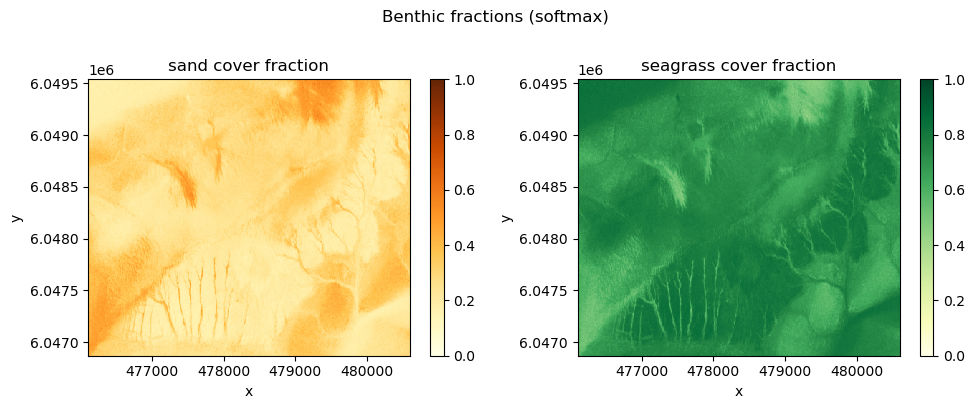

Type             median fraction  mean fraction
-----------------------------------------------
sand                        0.27           0.28
seagrass                    0.73           0.72


In [30]:
fractions  = np.array(oe_engine.bottom_fractions(results['x_hat'], setup.fit_names))
# shape: (n_rows, n_cols, n_active_types)  where n_active_types = len(bottom_types)
type_names = [_LUT_NAMES[i] for i in bottom_types]
cmaps      = ['YlOrBr', 'YlGn', 'Blues', 'Purples', 'Oranges', 'Greens']

fig, axes = plt.subplots(1, len(type_names), figsize=(5 * len(type_names), 4))
axes = np.atleast_1d(axes)

for ax, name, j in zip(axes, type_names, range(len(type_names))):
    da = xr.DataArray(
        fractions[..., j],
        dims=tuple(spatial_dim_names),
        coords=spatial_coords,
    )
    da.plot(ax=ax, vmin=0, vmax=1, cmap=cmaps[j % len(cmaps)])
    ax.set_title(f'{name} cover fraction')

plt.suptitle('Benthic fractions (softmax)', y=1.01)
plt.tight_layout()
plt.show()

print(f"{'Type':<15}  {'median fraction':>15}  {'mean fraction':>13}")
print('-' * 47)
for name, j in zip(type_names, range(len(type_names))):
    print(f'{name:<15}  {np.nanmedian(fractions[..., j]):>15.2f}  {np.nanmean(fractions[..., j]):>13.2f}')